## LightGBM — Aplicação Operacional

**Objetivo:** aplicar o modelo LightGBM treinado com dados históricos de
2016-2019 em dados reais de junho de 2026 para:

1. **Avaliar a capacidade de generalização temporal** — verificar se o modelo
   mantém desempenho aceitável 7 anos após o período de treinamento, em um
   contexto onde padrões de emissão e tráfego urbano podem ter mudado.

2. **Simular uso operacional** — reproduzir o fluxo real de previsão:
   carregar modelo salvo, aplicar feature engineering nos dados recentes e
   gerar previsão de PM2.5 para as próximas 24h.

3. **Comparar previsão com observado** — avaliar o erro hora a hora e as
   métricas de desempenho (MAE, RMSE, R², MAPE, MBE) para o período previsto.

---

**Configuração do experimento:**

- Modelo: LightGBM GBDT treinado com dados da estação Congonhas (2016-2019)
- Dados de entrada: 30 dias de observações reais (maio-junho 2026)
- Corte: 2026-06-22 23:00 UTC 
- Previsão: 2026-06-23 00:00 UTC → 2026-06-23 23:00 UTC (24h)
- Avaliação: comparação hora a hora com dados observados da estação



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# Carrega modelo e lista de features do treinamento
model    = joblib.load("../models/lightgbm_pm25.pkl")
features = joblib.load("../models/lightgbm_features.pkl")

print(f"Modelo carregado: {type(model).__name__}")
print(f"Features esperadas: {len(features)}")

Modelo carregado: LGBMRegressor
Features esperadas: 46


In [ ]:
features

['temperature_2m',
 'relative_humidity_2m',
 'precipitation',
 'wind_speed_10m',
 'month_sin',
 'month_cos',
 'weekday_sin',
 'weekday_cos',
 'hour_sin',
 'hour_cos',
 'temperature_2m_lag1',
 'temperature_2m_lag3',
 'temperature_2m_lag6',
 'temperature_2m_lag12',
 'temperature_2m_lag24',
 'relative_humidity_2m_lag1',
 'relative_humidity_2m_lag3',
 'relative_humidity_2m_lag6',
 'relative_humidity_2m_lag12',
 'relative_humidity_2m_lag24',
 'wind_speed_10m_lag1',
 'wind_speed_10m_lag3',
 'wind_speed_10m_lag6',
 'wind_speed_10m_lag12',
 'wind_speed_10m_lag24',
 'pm25_lag1',
 'pm25_lag2',
 'pm25_lag3',
 'pm25_lag6',
 'pm25_lag12',
 'pm25_lag24',
 'pm25_lag48',
 'pm25_lag168',
 'is_winter',
 'pm25_mean_6h',
 'pm25_std_6h',
 'pm25_max_6h',
 'pm25_mean_12h',
 'pm25_std_12h',
 'pm25_max_12h',
 'pm25_mean_24h',
 'pm25_std_24h',
 'pm25_max_24h',
 'pm25_mean_48h',
 'pm25_std_48h',
 'pm25_max_48h']

In [3]:
#  Carrega dados com feature engineering já aplicada
df = pd.read_csv(
    "../data/operational/dados_features_engineering_gaps_UTC_20260624.csv",
    index_col=0,
    parse_dates=True
)

df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()

print(f"\nDados carregados: {df.shape}")
print(f"Período completo: {df.index.min()} → {df.index.max()}")
print(f"NaN total: {df.isna().sum().sum()}")


Dados carregados: (747, 47)
Período completo: 2026-05-24 01:00:00+00:00 → 2026-06-24 03:00:00+00:00
NaN total: 672


In [4]:
df.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,pm25_max_6h,pm25_mean_12h,pm25_std_12h,pm25_max_12h,pm25_mean_24h,pm25_std_24h,pm25_max_24h,pm25_mean_48h,pm25_std_48h,pm25_max_48h
time,,,,,,,,,,,,,,,,,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691,0.5,-0.866025,-0.781831,0.62349,0.258819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000,0.5,-0.866025,-0.781831,0.62349,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416,0.5,-0.866025,-0.781831,0.62349,0.707107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968,0.5,-0.866025,-0.781831,0.62349,0.866025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143,0.5,-0.866025,-0.781831,0.62349,0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# o arquivo vai até 2026-06-24 00:00
# queremos prever as 24h do dia 23 (00h até 23h)

CORTE = "2026-06-22 23:00:00+00:00"

df_input = df[df.index <= CORTE].copy()
df_alvo  = df[df.index >  CORTE].copy()

print(f"X entrada : {df_input.index[-1]}")
print(f"Y alvo    : {df_alvo.index[0]} → {df_alvo.index[-1]}")

X entrada : 2026-06-22 23:00:00+00:00
Y alvo    : 2026-06-23 00:00:00+00:00 → 2026-06-24 03:00:00+00:00


In [12]:
df_input.head()

,MP2.5,temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m,month_sin,month_cos,weekday_sin,weekday_cos,hour_sin,...,pm25_max_6h,pm25_mean_12h,pm25_std_12h,pm25_max_12h,pm25_mean_24h,pm25_std_24h,pm25_max_24h,pm25_mean_48h,pm25_std_48h,pm25_max_48h
time,,,,,,,,,,,,,,,,,,,,,
2026-05-24 01:00:00+00:00,43.0,16.10,97.165480,0.4,3.284691,0.5,-0.866025,-0.781831,0.62349,0.258819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 02:00:00+00:00,45.0,16.00,98.730400,0.9,5.400000,0.5,-0.866025,-0.781831,0.62349,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 03:00:00+00:00,39.4,15.85,97.784970,0.2,7.895416,0.5,-0.866025,-0.781831,0.62349,0.707107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 04:00:00+00:00,43.3,15.40,98.724525,0.2,3.494968,0.5,-0.866025,-0.781831,0.62349,0.866025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-24 05:00:00+00:00,49.2,15.40,98.724525,0.6,2.099143,0.5,-0.866025,-0.781831,0.62349,0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# verifica se as features existem no arquivo
features_faltando = [f for f in features if f not in df_input.columns]
if features_faltando:
    print(f"\n⚠️  Features faltando: {features_faltando}")
else:
    print(f"\n✅ Todas as {len(features)} features presentes")


✅ Todas as 46 features presentes


In [7]:
# usa as features do df_alvo (dia 23) que já têm os lags calculados
# com base nos dados do dia 22 e anteriores
X_previsao = df_alvo[features].iloc[:24].copy()

print(f"\nX de previsão: {X_previsao.index.min()} → {X_previsao.index.max()}")

print(f"NaN em X_previsao: {X_previsao.isna().sum().sum()}")


y_pred = model.predict(X_previsao)



X de previsão: 2026-06-23 00:00:00+00:00 → 2026-06-23 23:00:00+00:00
NaN em X_previsao: 0


In [8]:
# índice é o próprio índice do dia 23
previsao_24h = pd.Series(
    y_pred,
    index=X_previsao.index,
    name="pm25_previsto"
)

print(f"\nPrevisão gerada:")
print(f"  Período: {previsao_24h.index.min()} → {previsao_24h.index.max()}")
print(f"  Min previsto : {previsao_24h.min():.1f} µg/m³")
print(f"  Max previsto : {previsao_24h.max():.1f} µg/m³")
print(f"  Média prevista: {previsao_24h.mean():.1f} µg/m³")


Previsão gerada:
  Período: 2026-06-23 00:00:00+00:00 → 2026-06-23 23:00:00+00:00
  Min previsto : 7.6 µg/m³
  Max previsto : 24.5 µg/m³
  Média prevista: 12.0 µg/m³


In [13]:
data_previsao = previsao_24h.index.min().strftime("%Y%m%d")

# Salvar
previsao_24h.to_csv(f"../data/forecast/forecast_LGBM_{data_previsao}.csv",
   index=True
)

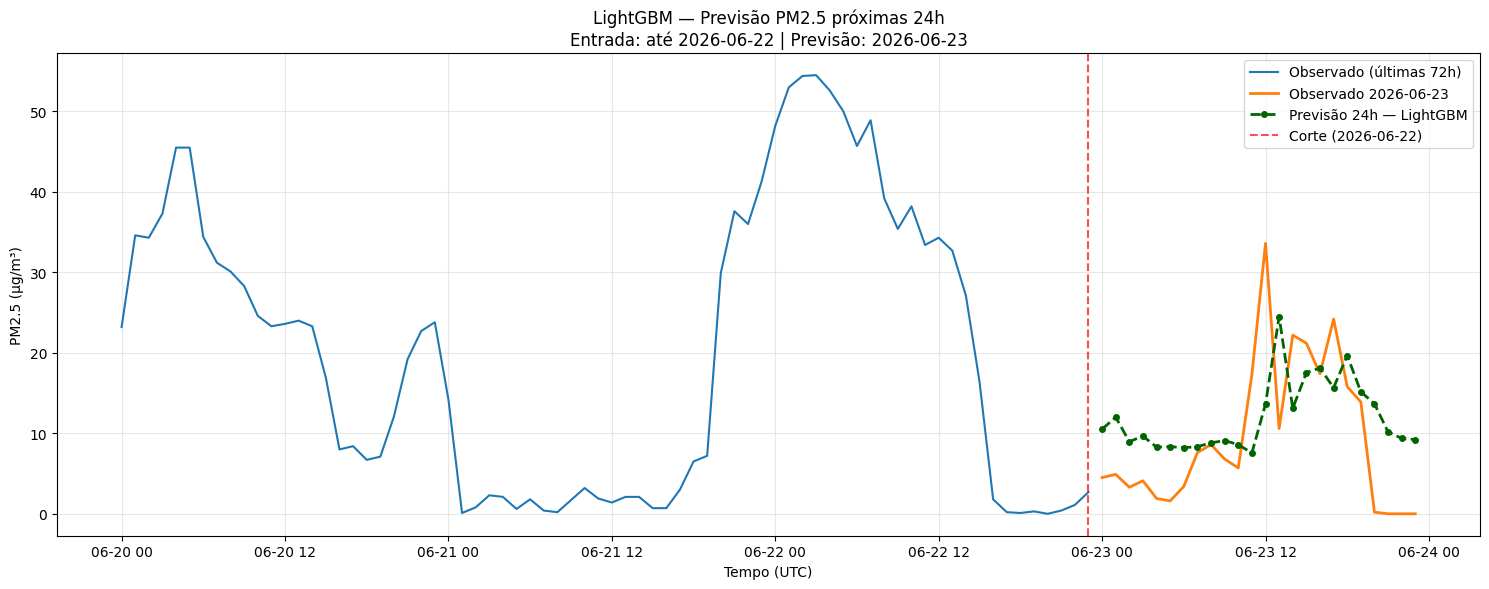

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))

# contexto: últimas 72h observadas
ax.plot(
    df_input["MP2.5"].iloc[-72:],
    label="Observado (últimas 72h)",
    color="tab:blue", linewidth=1.5
)

# observado do dia 24 — y real para comparação
ax.plot(
    df_alvo["MP2.5"].iloc[:24],
    label="Observado 2026-06-23",
    color="tab:orange", linewidth=2
)

# previsão
ax.plot(
    previsao_24h,
    label="Previsão 24h — LightGBM",
    color="darkgreen", linewidth=2,
    linestyle="--", marker="o", markersize=4
)

ax.axvline(
    pd.Timestamp(CORTE, tz="UTC"),
    color="red", linestyle="--", alpha=0.7,
    label=f"Corte ({CORTE[:10]})"
)

data_alvo = df_alvo.index[0].strftime("%Y-%m-%d")
ax.set_title("LightGBM — Previsão PM2.5 próximas 24h\n"
             f"Entrada: até {CORTE[:10]} | Previsão: {data_alvo}")
ax.set_xlabel("Tempo (UTC)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
if len(df_alvo) >= 24:

    y_real = df_alvo["MP2.5"].iloc[:24]

    comparacao = pd.DataFrame({
        "observado" : y_real.values,
        "previsto"  : previsao_24h.values
    }, index=previsao_24h.index)

    # --- métricas ---
    mae  = mean_absolute_error(comparacao["observado"], comparacao["previsto"])
    rmse = np.sqrt(mean_squared_error(comparacao["observado"], comparacao["previsto"]))
    r2   = r2_score(comparacao["observado"], comparacao["previsto"])

    # MAPE
    mask_nao_zero = comparacao["observado"] != 0
    mape = (
        100 * (
            (comparacao["observado"][mask_nao_zero] - comparacao["previsto"][mask_nao_zero])
            .abs() / comparacao["observado"][mask_nao_zero]
        ).mean()
    )

    # MBE
    mbe = (comparacao["previsto"] - comparacao["observado"]).mean()

    # NMAE
    nmae = 100 * mae / comparacao["observado"].mean()

    print("=" * 45)
    data_alvo = df_alvo.index[0].strftime("%Y-%m-%d")
    print(f"Métricas — Avaliação {data_alvo}")
    print("-" * 45)
    print(f"MAE   : {mae:.3f} µg/m³")
    print(f"RMSE  : {rmse:.3f} µg/m³")
    print(f"R²    : {r2:.4f}")
    print(f"MAPE  : {mape:.2f}%   (erro percentual médio)")
    print(f"MBE   : {mbe:.3f} µg/m³  ({'superestima' if mbe > 0 else 'subestima'})")
    print(f"NMAE  : {nmae:.2f}%   (MAE / média observada)")
    print("=" * 45)

    # comparação com desempenho no treino
    print(f"\nComparação com validação 2018:")
    print(f"  MAE  validação 2018 : 4.14 µg/m³")
    print(f"  MAE  dados 2026     : {mae:.3f} µg/m³")
    print(f"  Diferença           : {mae - 4.14:+.3f} µg/m³")

Métricas — Avaliação 2026-06-23
---------------------------------------------
MAE   : 6.725 µg/m³
RMSE  : 8.174 µg/m³
R²    : 0.1706
MAPE  : 414.07%   (erro percentual médio)
MBE   : 2.474 µg/m³  (superestima)
NMAE  : 70.54%   (MAE / média observada)

Comparação com validação 2018:
  MAE  validação 2018 : 4.14 µg/m³
  MAE  dados 2026     : 6.725 µg/m³
  Diferença           : +2.585 µg/m³
